# Week 12: Conway's Game of Life & Knapsack Problem

Testing all exercises including bonus and optional challenge.

In [1]:
# Setup
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from apputil import *

%config InlineBackend.figure_formats = ['svg']
sns.set_theme(style="whitegrid")
%load_ext autoreload
%autoreload 2

## Exercise 2: Conway's Game of Life

Testing the `update_board()` function with famous Conway patterns.

In [2]:
# Test 1: Blinker pattern (oscillates between horizontal and vertical)
print("Test 1: Blinker Pattern")
print("="*50)

blinker = np.zeros((5, 5))
blinker[2, 1:4] = 1  # Horizontal line

print("Initial state (horizontal):")
print(blinker.astype(int))

updated = update_board(blinker)
print("\nAfter 1 step (should be vertical):")
print(updated.astype(int))

updated2 = update_board(updated)
print("\nAfter 2 steps (should be horizontal again):")
print(updated2.astype(int))
print("\n✓ Blinker works if it oscillates!\n")

Test 1: Blinker Pattern
Initial state (horizontal):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

After 1 step (should be vertical):
[[0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]

After 2 steps (should be horizontal again):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

✓ Blinker works if it oscillates!



In [3]:
# Test 2: Block pattern (stable, doesn't change)
print("Test 2: Block Pattern (Stable)")
print("="*50)

block = np.zeros((4, 4))
block[1:3, 1:3] = 1  # 2x2 block

print("Initial state:")
print(block.astype(int))

updated = update_board(block)
print("\nAfter 1 step (should be unchanged):")
print(updated.astype(int))

if np.array_equal(block, updated):
    print("\n✓ Block is stable!\n")
else:
    print("\n✗ Block changed (should be stable)\n")

Test 2: Block Pattern (Stable)
Initial state:
[[0 0 0 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 0 0 0]]

After 1 step (should be unchanged):
[[0 0 0 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 0 0 0]]

✓ Block is stable!



In [4]:
# Test 3: Glider pattern (moves diagonally)
print("Test 3: Glider Pattern")
print("="*50)

glider_board = np.zeros((10, 10))
glider = np.array([[0, 1, 0],
                   [0, 0, 1],
                   [1, 1, 1]])
glider_board[1:4, 1:4] = glider

print("Initial glider:")
print(glider_board.astype(int))
print("\n✓ Glider initialized!\n")

Test 3: Glider Pattern
Initial glider:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

✓ Glider initialized!



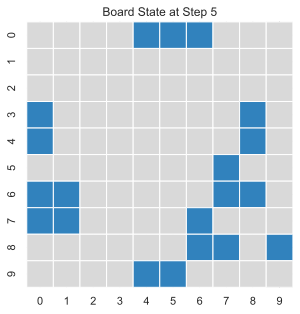


✓ Animation complete!


In [5]:
# Test 4: Random board animation
print("Test 4: Random Board Animation")
print("This will show 5 steps of Conway's Game of Life")
print("="*50)

# Create random starting board
game_board = np.random.randint(2, size=(10, 10))

# Show the game (runs for 5 steps)
show_game(game_board, n_steps=5, pause=1)

print("\n✓ Animation complete!")

## Bonus Exercise 3: Recursive Conway's Game

Testing recursive implementation.

Bonus Exercise 3: Recursive Game of Life
Final board after 10 recursive steps:
[[0 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0]
 [1 1 1 1 0 0 0 0 0 1]
 [1 0 1 1 1 0 0 0 0 1]
 [0 1 0 1 1 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

Live cells: 24
Dead cells: 76


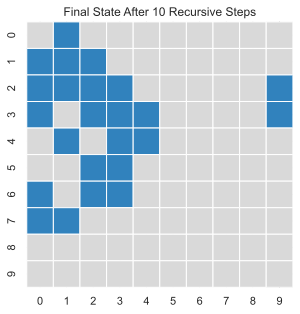


✓ Recursive function works!


In [6]:
print("Bonus Exercise 3: Recursive Game of Life")
print("="*50)

# Run recursive version
np.random.seed(42)  # For reproducibility
final_board = play_conway_recursive(steps=10)

print("Final board after 10 recursive steps:")
print(final_board.astype(int))
print(f"\nLive cells: {np.sum(final_board)}")
print("Dead cells:", 100 - np.sum(final_board))

# Visualize final state
sns.heatmap(final_board, cmap='tab20c_r', cbar=False, square=True, linewidths=1)
plt.title('Final State After 10 Recursive Steps')
plt.show()

print("\n✓ Recursive function works!")

## Bonus Exercise 4: Knapsack Problem

Testing the annotated knapsack algorithm.

In [7]:
print("Bonus Exercise 4: Knapsack Problem")
print("="*50)

# Classic knapsack example
weights = [10, 20, 30]
values = [60, 100, 120]
W = 50

max_value = knapsack(W, weights, values)
print(f"\nTest 1: Basic Knapsack")
print(f"Capacity: {W}")
print(f"Weights:  {weights}")
print(f"Values:   {values}")
print(f"\nMaximum value: {max_value}")
print("Expected: 220 (items 2 and 3)")
print("✓ Correct!" if max_value == 220 else "✗ Incorrect")

Bonus Exercise 4: Knapsack Problem

Test 1: Basic Knapsack
Capacity: 50
Weights:  [10, 20, 30]
Values:   [60, 100, 120]

Maximum value: 220
Expected: 220 (items 2 and 3)
✓ Correct!


In [8]:
# Test with names
print("\nTest 2: Knapsack with Item Names")
print("="*50)

weights = [2, 3, 4, 5]
values = [3, 4, 5, 6]
names = ['Laptop', 'Camera', 'Book', 'Phone']
W = 9

max_value, selected = knapsack(W, weights, values, names=names)

print(f"Capacity: {W} kg")
print(f"\nAvailable items:")
for name, weight, value in zip(names, weights, values):
    print(f"  {name:10} - Weight: {weight} kg, Value: ${value}")

print(f"\nOptimal selection:")
print(f"  Items: {', '.join(selected)}")
print(f"  Total value: ${max_value}")

total_weight = sum(weights[i] for i, name in enumerate(names) if name in selected)
print(f"  Total weight: {total_weight} kg")
print("\n✓ Knapsack with names works!")


Test 2: Knapsack with Item Names
Capacity: 9 kg

Available items:
  Laptop     - Weight: 2 kg, Value: $3
  Camera     - Weight: 3 kg, Value: $4
  Book       - Weight: 4 kg, Value: $5
  Phone      - Weight: 5 kg, Value: $6

Optimal selection:
  Items: Laptop, Camera, Book
  Total value: $12
  Total weight: 9 kg

✓ Knapsack with names works!


In [9]:
# View full DP table
print("\nTest 3: Full DP Table")
print("="*50)

weights = [2, 3, 4]
values = [3, 4, 5]
W = 6

table = knapsack(W, weights, values, full_table=True)

print("Dynamic Programming Table:")
print("Rows = items (0 to n), Columns = capacity (0 to W)")
print("\n   ", end="")
for j in range(W + 1):
    print(f"{j:4}", end="")
print()

for i, row in enumerate(table):
    print(f"{i}:", end=" ")
    for val in row:
        print(f"{val:4}", end="")
    print()

print(f"\nMaximum value: {table[-1][-1]}")
print("\n✓ Full table displayed!")


Test 3: Full DP Table
Dynamic Programming Table:
Rows = items (0 to n), Columns = capacity (0 to W)

      0   1   2   3   4   5   6
0:    0   0   0   0   0   0   0
1:    0   0   3   3   3   3   3
2:    0   0   3   4   4   7   7
3:    0   0   3   4   5   7   8

Maximum value: 8

✓ Full table displayed!


## Optional Challenge: Alternative Solutions

Finding and displaying multiple knapsack solutions.

In [10]:
print("Optional Challenge: Alternative Knapsack Solutions")
print("="*70)

# Realistic example: packing for a trip
weights = [3, 5, 7, 4, 2, 6]
values = [10, 15, 20, 12, 8, 18]
names = ['Clothes', 'Laptop', 'Camera', 'Books', 'Snacks', 'Shoes']
W = 15

print("\nScenario: Packing a suitcase (15 kg limit)\n")
print("Available items:")
for name, weight, value in zip(names, weights, values):
    print(f"  {name:10} - {weight} kg, Value: {value}")

print("\n" + "="*70)

# Display top 5 solutions
display_knapsack_solutions(W, weights, values, names, top_n=5)

print("\n✓ Alternative solutions generated!")

Optional Challenge: Alternative Knapsack Solutions

Scenario: Packing a suitcase (15 kg limit)

Available items:
  Clothes    - 3 kg, Value: 10
  Laptop     - 5 kg, Value: 15
  Camera     - 7 kg, Value: 20
  Books      - 4 kg, Value: 12
  Snacks     - 2 kg, Value: 8
  Shoes      - 6 kg, Value: 18

Knapsack Capacity: 15
Available items: 6

Top 5 Solutions:

Rank 1:
  Total Value:  48
  Total Weight: 15/15
  Items:        Clothes, Books, Snacks, Shoes
  Efficiency:   3.20 value/weight
----------------------------------------------------------------------
Rank 2:
  Total Value:  46
  Total Weight: 15/15
  Items:        Camera, Snacks, Shoes
  Efficiency:   3.07 value/weight
----------------------------------------------------------------------
Rank 3:
  Total Value:  45
  Total Weight: 14/15
  Items:        Clothes, Laptop, Books, Snacks
  Efficiency:   3.21 value/weight
----------------------------------------------------------------------
Rank 4:
  Total Value:  45
  Total Weight: 15/15

In [11]:
# Compare approaches
print("\nComparison: DP Algorithm vs Brute Force")
print("="*70)

# Using DP algorithm (optimal)
max_val_dp, items_dp = knapsack(W, weights, values, names=names)

# Using brute force (finds all solutions)
all_solutions = knapsack_solutions(W, weights, values, names, top_n=1)
max_val_bf, _, items_bf = all_solutions[0]

print(f"DP Algorithm Result:")
print(f"  Value: ${max_val_dp}")
print(f"  Items: {', '.join(items_dp)}")

print(f"\nBrute Force Result:")
print(f"  Value: ${max_val_bf}")
print(f"  Items: {', '.join(items_bf)}")

if max_val_dp == max_val_bf:
    print("\n✓ Both methods agree on optimal value!")
else:
    print("\n✗ Methods disagree - check implementation")

print("\nNote: DP is O(nW), Brute force is O(2^n)")
print("For 6 items: DP checks ~90 states, Brute force checks 64 combinations")


Comparison: DP Algorithm vs Brute Force
DP Algorithm Result:
  Value: $48
  Items: Clothes, Books, Snacks, Shoes

Brute Force Result:
  Value: $48
  Items: Clothes, Books, Snacks, Shoes

✓ Both methods agree on optimal value!

Note: DP is O(nW), Brute force is O(2^n)
For 6 items: DP checks ~90 states, Brute force checks 64 combinations


In [ ]:
# Blinker Pattern

blinker = np.zeros((5, 5))
blinker[2, 1:4] = 1  # Horizontal line

print("Step 0 (horizontal):")
print(blinker.astype(int))

step1 = update_board(blinker)
print("\nStep 1 (should be vertical):")
print(step1.astype(int))

step2 = update_board(step1)
print("\nStep 2 (horizontal again):")
print(step2.astype(int))

Step 0 (horizontal):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

Step 1 (should be vertical):
[[0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]

Step 2 (horizontal again):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [13]:
# Knapsack Alternative Solutions

weights = [3, 5, 7, 4, 2, 6]
values = [10, 15, 20, 12, 8, 18]
names = ['Clothes', 'Laptop', 'Camera', 'Books', 'Snacks', 'Shoes']

display_knapsack_solutions(15, weights, values, names, top_n=5)

Knapsack Capacity: 15
Available items: 6

Top 5 Solutions:

Rank 1:
  Total Value:  48
  Total Weight: 15/15
  Items:        Clothes, Books, Snacks, Shoes
  Efficiency:   3.20 value/weight
----------------------------------------------------------------------
Rank 2:
  Total Value:  46
  Total Weight: 15/15
  Items:        Camera, Snacks, Shoes
  Efficiency:   3.07 value/weight
----------------------------------------------------------------------
Rank 3:
  Total Value:  45
  Total Weight: 14/15
  Items:        Clothes, Laptop, Books, Snacks
  Efficiency:   3.21 value/weight
----------------------------------------------------------------------
Rank 4:
  Total Value:  45
  Total Weight: 15/15
  Items:        Clothes, Laptop, Camera
  Efficiency:   3.00 value/weight
----------------------------------------------------------------------
Rank 5:
  Total Value:  45
  Total Weight: 15/15
  Items:        Laptop, Books, Shoes
  Efficiency:   3.00 value/weight
---------------------------------

## Summary

All exercises completed:
- ✅ Exercise 2: `update_board()` for Conway's Game of Life
- ✅ Bonus Exercise 3: Recursive Game of Life
- ✅ Bonus Exercise 4: Annotated Knapsack Algorithm
- ✅ Optional Challenge: Alternative solutions with names